In [2]:
# Imports + load minimalist EDA file
import pandas as pd
from pathlib import Path
import numpy as np
path = Path("data/analysis/servicelines_with_imputed_materials.csv")
df = pd.read_csv(path)

C:\Users\bradk\AppData\Local\Temp\ipykernel_9176\132917980.py:6: DtypeWarning: Columns (31,32,33,34,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [39]:
# Print value counts for disadvantaged population variables

for col in ["sensitivepop", "disadvantaged","J40_TotCatExceeded"]:
    print(f"\nValue counts for {col}:")
    counts = df[col].value_counts(dropna=False)
    percents = df[col].value_counts(normalize=True, dropna=False) * 100
    result = pd.DataFrame({"count": counts, "percent": percents.round(1)})
    print(result)



Value counts for sensitivepop:
               count  percent
sensitivepop                 
No             63918     79.5
Yes - MFH      16014     19.9
Yes - School     344      0.4
Yes - Daycare     98      0.1

Value counts for disadvantaged:
               count  percent
disadvantaged                
No             44376     55.2
Yes            35998     44.8

Value counts for J40_TotCatExceeded:
                    count  percent
J40_TotCatExceeded                
0                   44376     55.2
999                 35998     44.8


In [40]:
# Racial breakdown of neighborhoods

race_path = "data_derived/neighborhoods_from_matches_race.csv"
race_df = pd.read_csv(race_path)
race_df = race_df.sort_values(by="pct_black", ascending=False)
print(race_df)


                     Name  pct_white  pct_black  pct_hispanic  pct_asian  \
44              Fairfield   0.010240   0.971664      0.012619   0.000000   
41               Eastview   0.011966   0.967459      0.013168   0.000563   
37              Creighton   0.012247   0.967302      0.013381   0.000042   
53                 Gilpin   0.013735   0.963439      0.000366   0.000431   
146             Woodville   0.064531   0.899293      0.013383   0.006417   
..                    ...        ...        ...           ...        ...   
141                Wilton   0.898414   0.028202      0.013683   0.041143   
33         Colonial Place   0.918902   0.017617      0.023530   0.017763   
140           Willow lawn   0.925734   0.014558      0.021835   0.015460   
73           Mary Munford   0.954335   0.001335      0.015562   0.024563   
82   Monument Avenue Park   0.929619   0.000000      0.029326   0.017595   

       pct_native  pct_hipi  
44   9.491728e-08       0.0  
41   3.049138e-05       0.0

In [21]:
# Income breakdown of neighborhoods

income_path = "data_derived/neighborhoods_from_matches_income.csv"
income_df = pd.read_csv(income_path)
income_df = income_df.sort_values(by="householdincome_avghinc_cy", ascending=True)
print(income_df)

                Name  householdincome_avghinc_cy
53            Gilpin                19530.505375
44         Fairfield                24449.000000
41          Eastview                24615.053572
37         Creighton                25374.064376
83             Mosby                25531.000000
..               ...                         ...
140      Willow lawn               166963.035511
115  Stonewall Court               212209.444840
133      Westhampton               212233.074409
143    Windsor Farms               300494.314711
141           Wilton               301469.205750

[148 rows x 2 columns]


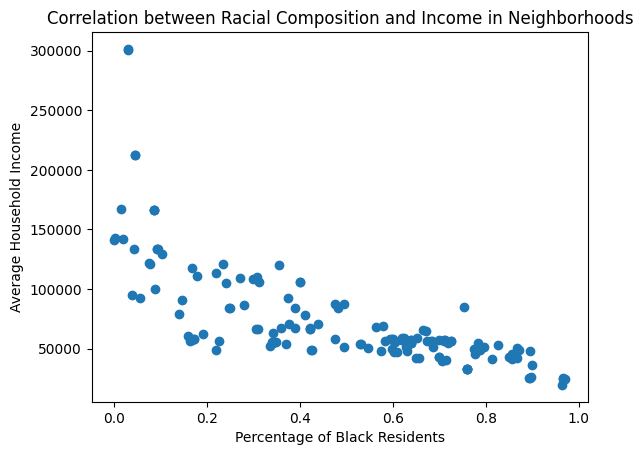

In [22]:
#Merge income df and race df. Correlate pct_black with householdincome_avghinc_cy. Visualize with scatter plot.
merged_df = pd.merge(race_df, income_df, on="Name", how="inner")
import matplotlib.pyplot as plt

plt.scatter(merged_df["pct_black"], merged_df["householdincome_avghinc_cy"])
plt.xlabel("Percentage of Black Residents")
plt.ylabel("Average Household Income")
plt.title("Correlation between Racial Composition and Income in Neighborhoods")
plt.show()

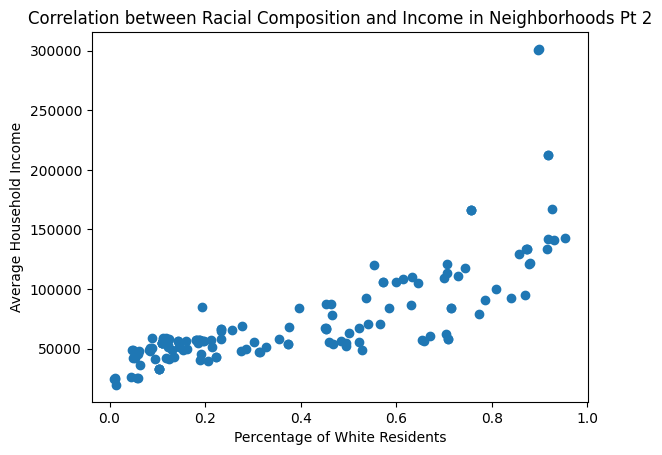

In [23]:
plt.scatter(merged_df["pct_white"], merged_df["householdincome_avghinc_cy"])
plt.xlabel("Percentage of White Residents")
plt.ylabel("Average Household Income")
plt.title("Correlation between Racial Composition and Income in Neighborhoods Pt 2")
plt.show()

In [24]:
lead_path = "data/analysis/neighborhoods_lead_summary.csv"
lead_df = pd.read_csv(lead_path)
lead_df = lead_df.sort_values(by="pct_lead_total", ascending=False)
print(lead_df)


                    Name  Lead  Non-Lead  Unknown  total_points  known_points  \
18             Byrd Park    74        72      482           628           146   
11            Broad Rock    63        19      461           543            82   
114              Stadium    27        15      205           247            42   
123  The Museum District   296       242     2277          2815           538   
122              The Fan   529       470     4159          5158           999   
..                   ...   ...       ...      ...           ...           ...   
135             Westover     0        85      869           954            85   
132      Washington Park     0        59      362           421            59   
142              Windsor     0         1       70            71             1   
144            Woodhaven     0        28      532           560            28   
147          Worthington     0        58      423           481            58   

     pct_lead_total  pct_no

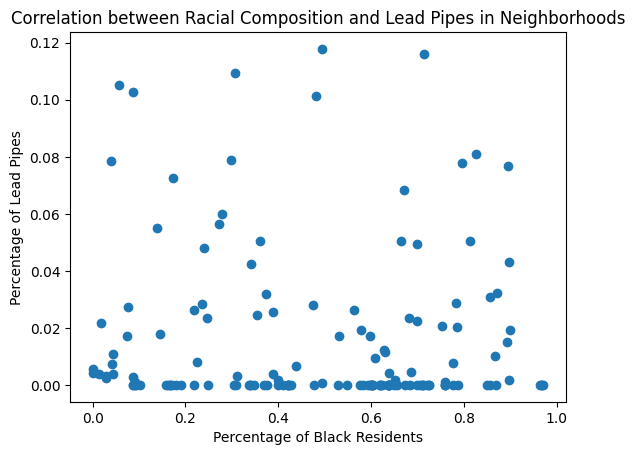

In [25]:
#Merge lead df with merged_df to see correlation between lead paint and racial/income data.
final_df = pd.merge(merged_df, lead_df, on="Name", how="inner") 
plt.scatter(final_df["pct_black"], final_df["pct_lead_total"])
plt.xlabel("Percentage of Black Residents")
plt.ylabel("Percentage of Lead Pipes")
plt.title("Correlation between Racial Composition and Lead Pipes in Neighborhoods")
plt.show()

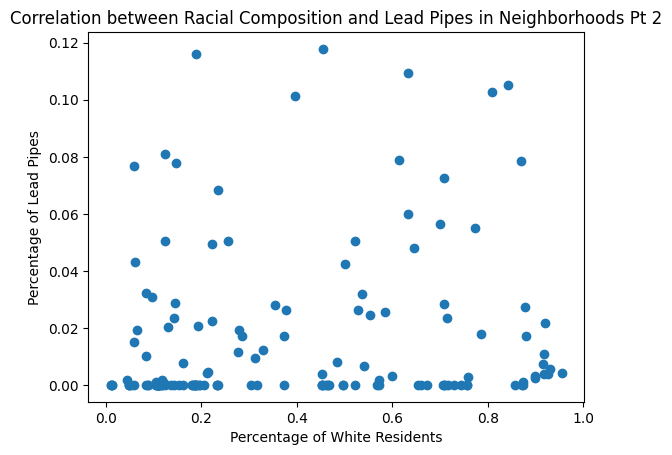

In [26]:
plt.scatter(final_df["pct_white"], final_df["pct_lead_total"])
plt.xlabel("Percentage of White Residents")
plt.ylabel("Percentage of Lead Pipes")
plt.title("Correlation between Racial Composition and Lead Pipes in Neighborhoods Pt 2")
plt.show()

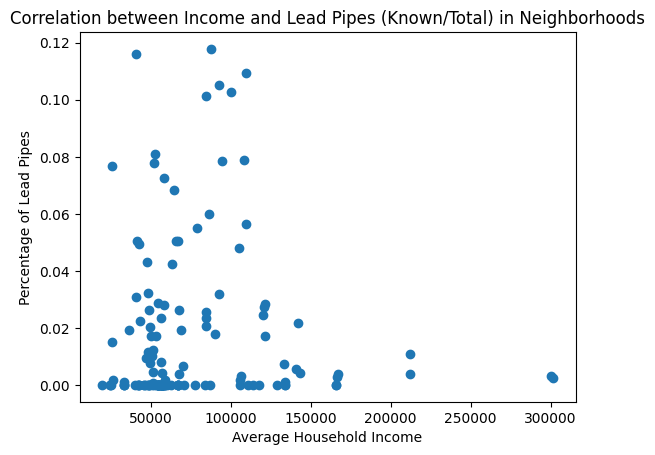

In [27]:
plt.scatter(final_df["householdincome_avghinc_cy"], final_df["pct_lead_total"])
plt.xlabel("Average Household Income")
plt.ylabel("Percentage of Lead Pipes")
plt.title("Correlation between Income and Lead Pipes (Known/Total) in Neighborhoods")
plt.show()

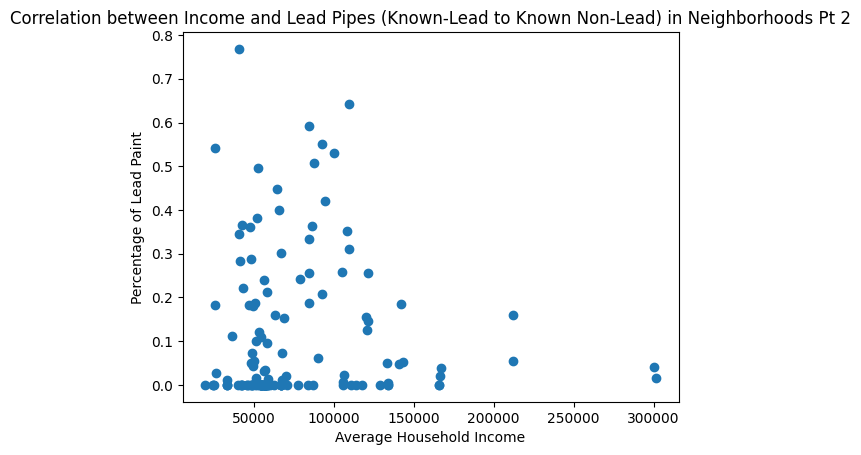

In [ ]:
plt.scatter(final_df["householdincome_avghinc_cy"], final_df["pct_lead_known"])
plt.xlabel("Average Household Income")
plt.ylabel("Percentage of Lead Pipes")
plt.title("Correlation between Income and Lead Pipes (Known-Lead to Known Non-Lead) in Neighborhoods Pt 2")
plt.show()

In [32]:
lead_imputed_path = "data/analysis/neighborhoods_lead_imputed_summary.csv"
lead_imputed_df = pd.read_csv(lead_imputed_path)
lead_imputed_df = lead_imputed_df.sort_values(by="lead_percent_bothsides_imputed", ascending=False)

# Rename neighborhood_name to Name for merging
lead_imputed_df = lead_imputed_df.rename(columns={"neighborhood_name": "Name"})

print(lead_imputed_df)


                    Name  total_count  lead_count_bothsides_imputed  \
55   Ginter Park Terrace          158                         140.0   
60      Highland Terrace          419                         363.0   
96            Peter Paul          324                         274.0   
122              The Fan         5158                        4357.0   
16        Brookland Park          870                         731.0   
..                   ...          ...                           ...   
97             Pine Camp           16                           0.0   
113            Southwood          389                           0.0   
100         Powhite Park           55                           0.0   
139          Willow Oaks          237                           0.0   
142              Windsor           71                           0.0   

     lead_percent_bothsides_imputed  lead_count_custmaterial_imputed  \
55                             88.6                            139.0   
60 

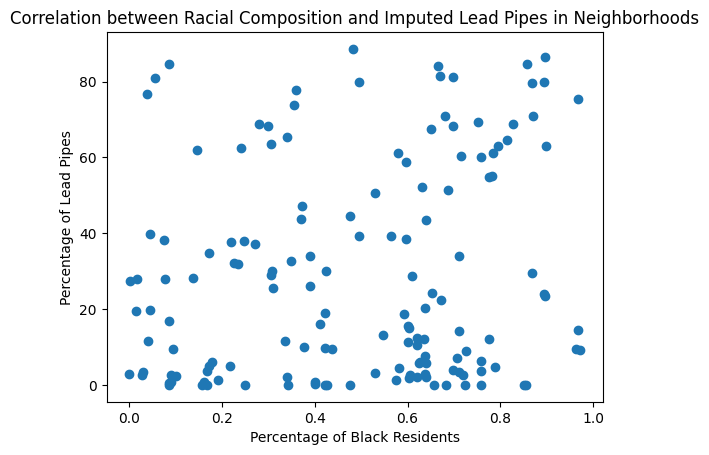

In [33]:
final_df2 = pd.merge(final_df, lead_imputed_df, on="Name", how="inner") 

plt.scatter(final_df2["pct_black"], final_df2["lead_percent_bothsides_imputed"])
plt.xlabel("Percentage of Black Residents")
plt.ylabel("Percentage of Lead Pipes")
plt.title("Correlation between Racial Composition and Imputed Lead Pipes in Neighborhoods")
plt.show()


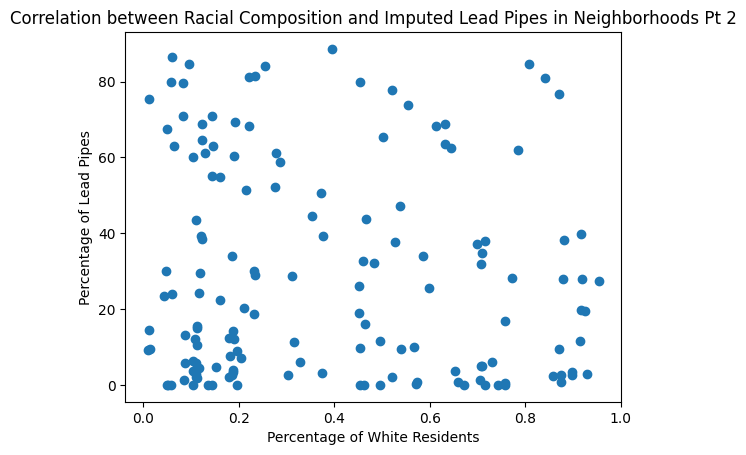

In [34]:

plt.scatter(final_df2["pct_white"], final_df2["lead_percent_bothsides_imputed"])
plt.xlabel("Percentage of White Residents")
plt.ylabel("Percentage of Lead Pipes")
plt.title("Correlation between Racial Composition and Imputed Lead Pipes in Neighborhoods Pt 2")
plt.show()


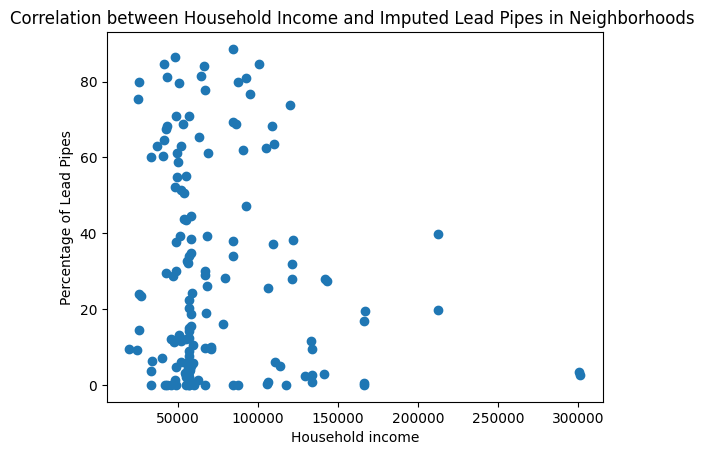

In [36]:

plt.scatter(final_df2["householdincome_avghinc_cy"], final_df2["lead_percent_bothsides_imputed"])
plt.xlabel("Household income")
plt.ylabel("Percentage of Lead Pipes")
plt.title("Correlation between Household Income and Imputed Lead Pipes in Neighborhoods ")
plt.show()


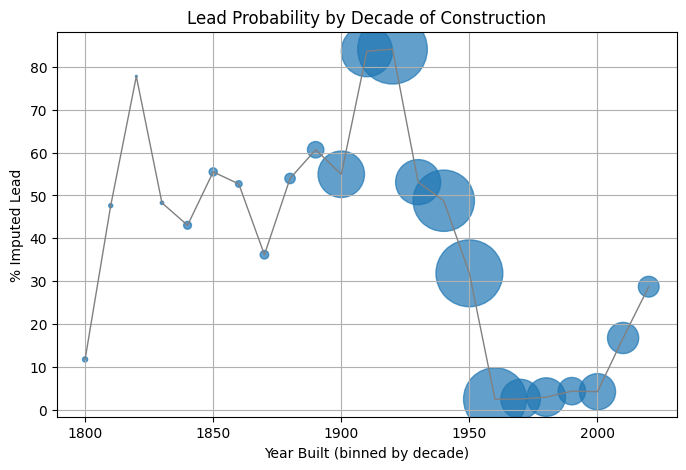

In [41]:
# binary flag for lead
df["lead_flag"] = (df["bothsidesstatus_imputed"] == "Lead/GRR").astype(int)

# drop missing years
df = df.dropna(subset=["yearstructbuilt"])
# drop years = "0"
df = df[df["yearstructbuilt"] > 0]
# drop future years
df = df[df["yearstructbuilt"] < 2026]
# bin by decade (or any bin width you like). 
df["year_bin"] = (df["yearstructbuilt"] // 10) * 10   # decade bins
#group all years before 1800
df.loc[df["yearstructbuilt"] < 1800, "year_bin"] = 1800

summary = df.groupby("year_bin")["lead_flag"].mean().reset_index()

#Weight dot size by number of samples in each bin
# compute count per bin, and merge by year_bin so indices align
counts = df.groupby("year_bin").size().reset_index(name="size")
summary = summary.merge(counts, on="year_bin", how="left")

plt.figure(figsize=(8,5))
plt.scatter(summary["year_bin"], summary["lead_flag"] * 100,
            s=summary["size"]/5, alpha=0.7)
plt.plot(summary["year_bin"], summary["lead_flag"] * 100, color="gray", linewidth=1)
plt.title("Lead Probability by Decade of Construction")
plt.xlabel("Year Built (binned by decade)")
plt.ylabel("% Imputed Lead")
plt.grid(True)
plt.show()

buildingtype
Single Family Residence      52241
Multiple Family Residence    16014
Building                     11729
Other                          390
Name: count, dtype: int64
buildingtype
Building                     0.240089
Multiple Family Residence    0.361621
Other                        0.138462
Single Family Residence      0.463659
Name: lead_flag, dtype: float64


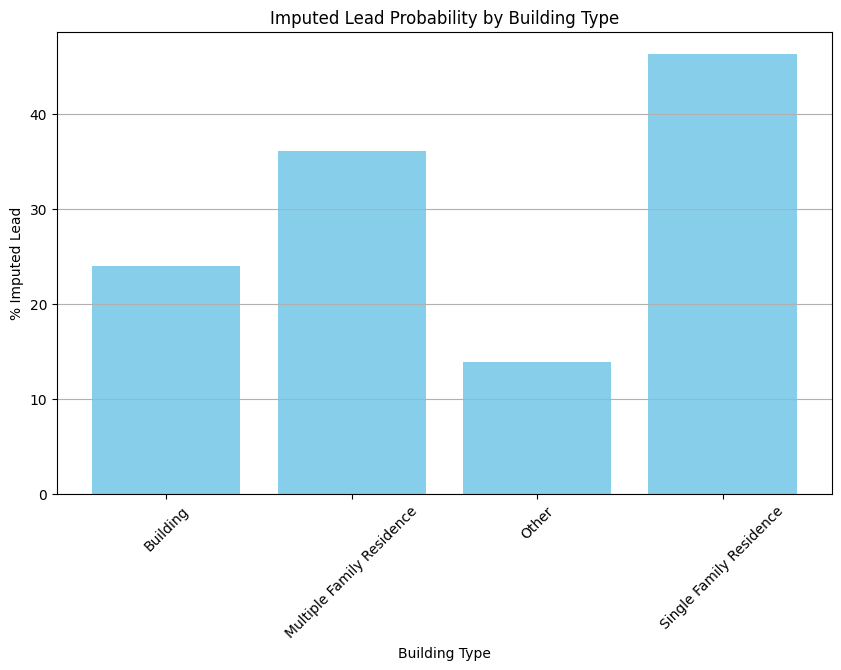

: 

In [ ]:
buildingtype_counts = df["buildingtype"].value_counts()
print(buildingtype_counts)
#Present imputed lead/non-lead status by building type
lead_by_buildingtype = df.groupby("buildingtype")["lead_flag"].mean()
print(lead_by_buildingtype)

#Graph lead probability by building type 

plt.figure(figsize=(10,6))
plt.bar(lead_by_buildingtype.index, lead_by_buildingtype.values * 100, color='skyblue')
plt.xlabel("Building Type")
plt.ylabel("% Imputed Lead")
plt.title("Imputed Lead Probability by Building Type")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()  


In [14]:
pd.options.display.max_rows = 4000

#print(df.head())
print(df['utilmaterial'].value_counts())
print(df['custmaterial'].value_counts())
print(df['bothsidesstatus'].value_counts())
print(df['ModelClassification_Cust'].value_counts())
print(df['ModelClassification_City'].value_counts())
print(df['utilmaterial_cat_imputed'].value_counts())
print(df['custmaterial_cat_imputed'].value_counts())
print(df['bothsidesstatus_imputed'].value_counts())
print()

utilmaterial
Non-Lead - Copper             36591
Unknown - Material Unknown    31354
Non-Lead - Other              11118
Lead                           1785
Galvanized                      454
Non-Lead - Plastic              346
Non-Lead                         90
Unknown                          35
Name: count, dtype: int64
custmaterial
Unknown - Material Unknown          65766
Non-Lead - Other                    13553
Non-Lead - Copper                    1055
Non-Lead - Plastic                    625
Lead                                  499
Non-Lead                              181
Galvanized                             89
Galvanized Requiring Replacement        3
Unknown                                 2
Name: count, dtype: int64
bothsidesstatus
Unknown                             65742
Non-Lead                            13770
Lead                                 2204
Galvanized Requiring Replacement       57
Name: count, dtype: int64
ModelClassification_Cust
1.0    34319
2.0    1